# Daily Data Fusion

Load individual daily data sources, align date ranges, merge into a single dataset, and remove highly correlated daily features.

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
chain_df = pd.read_parquet("../data/processed/chain/daily_cleaned.parquet")
market_df = pd.read_parquet('../data/processed/market/market_daily_cleaned.parquet')
reddit_df = pd.read_parquet('../data/processed/reddit/reddit_daily_cleaned.parquet')
twitter_df = pd.read_parquet('../data/processed/twitter/twitter_daily_cleaned.parquet')

### Filter data to research period

In [3]:
print("\nunique addresses in before filter:", len(chain_df['address'].unique()))
print(f"On-Chain Shape: {chain_df.shape}")
print(f"market Shape: {market_df.shape}")
print(f"reddit Shape: {reddit_df.shape}")
print(f"twitter Shape: {twitter_df.shape}")


unique addresses in before filter: 42476
On-Chain Shape: (1278876, 13)
market Shape: (3685, 6)
reddit Shape: (2886, 7)
twitter Shape: (2022, 14)


In [4]:
START_DATE = pd.to_datetime("2017-01-01").date()
END_DATE = pd.to_datetime("2021-02-10").date()

# Filter and align dates
for df in [chain_df, market_df, reddit_df, twitter_df]:
        df['day'] = pd.to_datetime(df['day']).dt.date

chain_df   = chain_df[(chain_df['day'] >= START_DATE) & (chain_df['day'] <= END_DATE)].copy()
market_df  = market_df[(market_df['day'] >= START_DATE) & (market_df['day'] <= END_DATE)].copy()
reddit_df  = reddit_df[(reddit_df['day'] >= START_DATE) & (reddit_df['day'] <= END_DATE)].copy()
twitter_df = twitter_df[(twitter_df['day'] >= START_DATE) & (twitter_df['day'] <= END_DATE)].copy()

print(f"Date range: {START_DATE} to {END_DATE}")

Date range: 2017-01-01 to 2021-02-10


In [5]:
print("\nunique addresses in after filter:", len(chain_df['address'].unique()))
print(f"On-Chain Shape: {chain_df.shape}")
print(f"market Shape: {market_df.shape}")
print(f"reddit Shape: {reddit_df.shape}")
print(f"twitter Shape: {twitter_df.shape}")


unique addresses in after filter: 35272
On-Chain Shape: (662714, 13)
market Shape: (1502, 6)
reddit Shape: (1502, 7)
twitter Shape: (1502, 14)


### Merge data

In [6]:
# Merge all off-chain data
offchain_df = (
    market_df
    .merge(reddit_df, on='day', how='outer')
    .merge(twitter_df, on='day', how='outer')
).sort_values('day')

# Merge on-chain with off-chain
daily_df = pd.merge(chain_df, offchain_df, on='day', how='left')

### Feature Selection: Daily Level

Drop highly correlated features before aggregation to reduce aggregation output size

In [7]:
daily_features_to_check = [
    # On-chain - 11
    "normal_sent_cnt", "normal_recv_cnt", "normal_total_cnt", "eth_sent_sum", "eth_recv_sum",
    "eth_net_flow", "uniq_peers_cnt", "sessions_cnt", "active_span_min", "burst_max_tx_5m",
    "days_since_last_activity",
    # Reddit - 6
    'reddit_fraud_mention_ratio', 'reddit_avg_sentiment', 'reddit_total_activity',
    'reddit_activity_spike', 'reddit_sentiment_std', 'reddit_total_fraud_mentions',
    # Twitter - 13
    'twitter_total_activity', 'twitter_avg_sentiment', 'twitter_sentiment_std',
    'twitter_avg_negative', 'twitter_avg_positive', 'twitter_negative_ratio',
    'twitter_fraud_mention_ratio', 'twitter_fraud_mention_count', 'twitter_avg_likes',
    'twitter_avg_retweets', 'twitter_avg_replies', 'twitter_activity_spike',
    'twitter_total_engagement',
    # Market - 5
    'market_daily_return', 'market_volatility_7d', 'market_volume_spike',
    'market_momentum_7d', 'market_intraday_volatility'
]

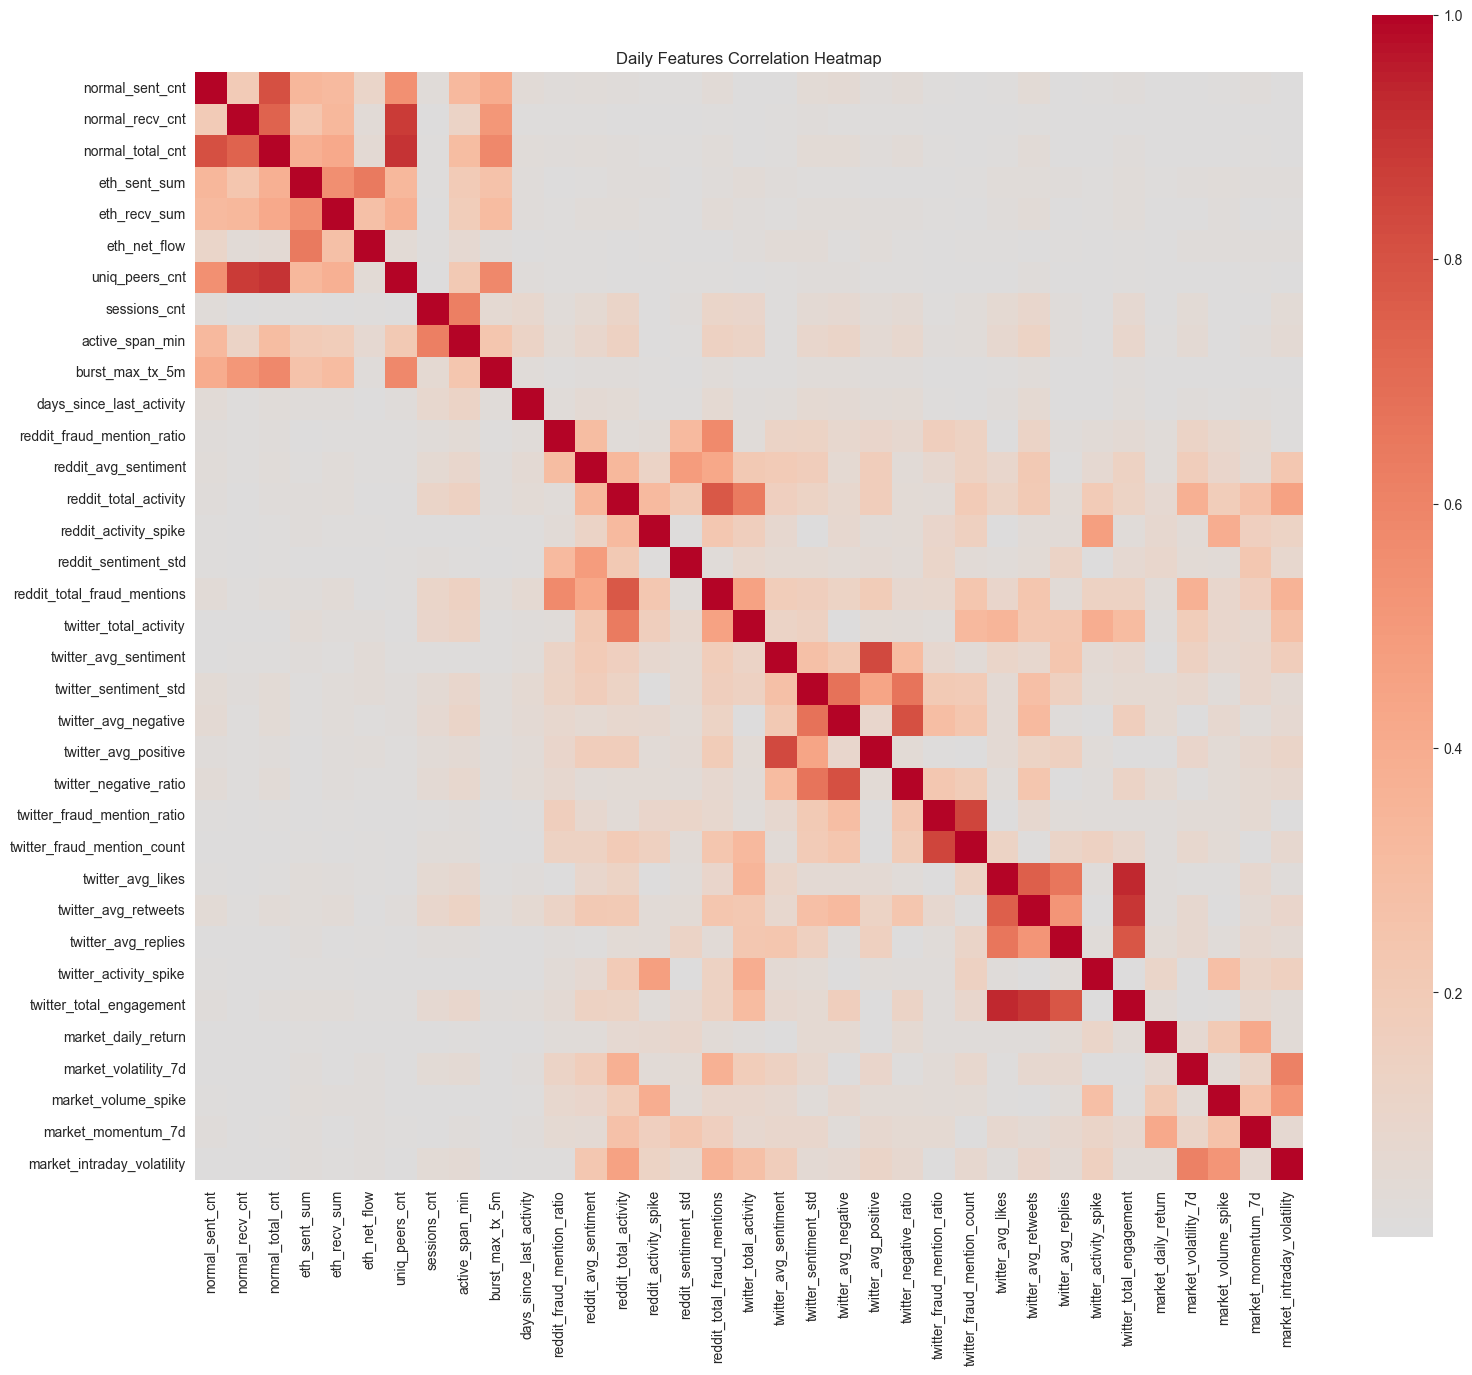

Dropping correlated daily features (3): ['uniq_peers_cnt', 'twitter_fraud_mention_count', 'twitter_total_engagement']


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check Correlation
corr_daily = daily_df[daily_features_to_check].corr().abs()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_daily, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Daily Features Correlation Heatmap')
plt.tight_layout()
plt.show()

upper_daily = corr_daily.where(np.triu(np.ones(corr_daily.shape), k=1).astype(bool))
daily_to_drop = [column for column in upper_daily.columns if any(upper_daily[column] > 0.85)]

print(f"Dropping correlated daily features ({len(daily_to_drop)}): {daily_to_drop}")

# Drop the columns
daily_df.drop(columns=daily_to_drop, inplace=True, errors='ignore')


In [9]:
output_dir = '../data/processed/final'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'daily_fused.parquet')
daily_df.to_parquet(output_path, index=False)
print(f"Final daily dataset shape: {daily_df.shape}")

Final daily dataset shape: (662714, 34)
